# Проверка логики алгоритмов в плагинах QGIS

In [1]:
import os

import osmnx as ox
import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import tabulate
import contextily as ctx

# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\nContextily', ctx.__version__,
      )

ox.settings.default_access = ''

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
Contextily 1.6.2


In [2]:
DATA_NODE_FIELD     = 'node'
UNITS_NAME_FIELD    = 'name'
# Для графа:
EDGES_WEIGHT_FIELD  = 'travel_time'
## Для матрицы прибытия:
DATA_SAMPLE_SIZE    = None
DATA_CUTOFF_FIELD   = None
# TARGET_SET          = None

## Для ADD:
NAMES_PATTERN       = '{}'
START_NAMES_INDEX   = 1

## Загрузка графа дорожной сети

<Axes: >

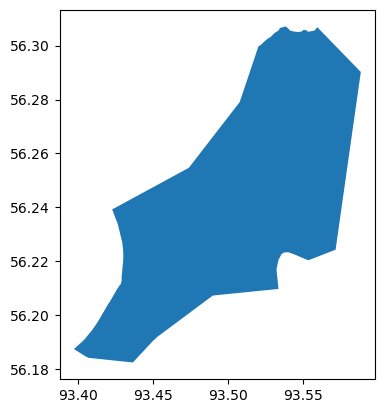

In [3]:
# Загрузка границ города
bounds = gpd.read_file('G:/QGIS/Железногорск/data/Железногорск.gpkg', layer='bounds')
bounds.plot()

In [4]:
# Загрузка графа дорог
bounds_buffer = ox.projection.project_gdf(bounds).buffer(2000)
bounds_buffer = ox.projection.project_gdf(bounds_buffer, to_latlong=True)
G = ox.graph_from_polygon(bounds_buffer.union_all(),
                            simplify         = False,
                            retain_all       = True,
                            truncate_by_edge = False,
                            network_type     = 'drive_service')

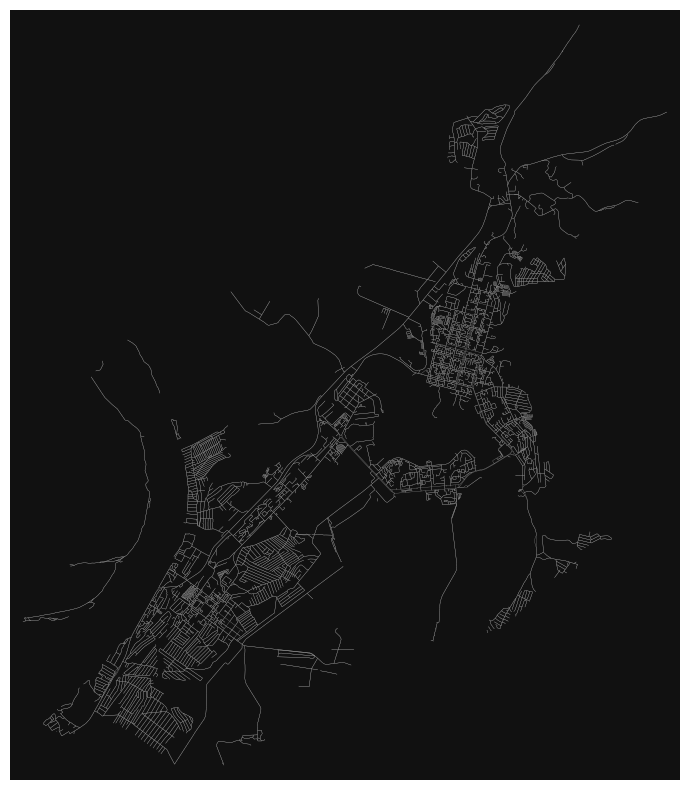

In [5]:
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, figsize=(10, 10));

In [6]:
# Сохраняем ребра графа как geopackage
ox.graph_to_gdfs(G, edges=True, nodes=False).to_file('roads_temp.gpkg', driver='GPKG');

## Служебные функции

In [7]:
def plot_map(borders, g_nodes, best_nodes):
    ## Улучшенная печать карты
    """
    Печать карты с границами города и узлами
    """
    # Настройка стиля графика
    plt.style.use('bmh')

    fig, ax = plt.subplots(figsize=(10, 10))
    borders.plot(ax=ax, color='#fcfcd9', edgecolor='black', linewidth=2, alpha=0.7, zorder=1)

    # Отображение узлов
    g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50, label='Размещение')

    # Подписи к узлам
    offset = (float(borders.bounds.iloc[0]['maxy']) - float(borders.bounds.iloc[0]['miny'])) / 100
    for node, unit in best_nodes.items():
        g_node_geometry = g_nodes.loc[node].geometry
        ax.text(
            g_node_geometry.x,
            g_node_geometry.y,
            str(unit),
            fontsize=10, 
            color='black',
            ha='center',
            va='bottom',
            position = (g_node_geometry.x, g_node_geometry.y + offset),
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='k', boxstyle='round,pad=0.2'),
            zorder=5
        )

    # Добавить подложку OSM
    ctx.add_basemap(ax, 
                    crs=g_nodes.crs, 
                    source=ctx.providers.OpenStreetMap.Mapnik, 
                    alpha=0.7, 
                    zorder=0)

    ax.legend(loc='upper left', fontsize=12, frameon=True)
    plt.tight_layout()
    plt.show()

## Расчеты

### Расчет с использованием оригинального графа

In [8]:
print(f'Количество узлов в оригинальном графе - {G.number_of_nodes()}, количество ребер - {G.number_of_edges()}')

Количество узлов в оригинальном графе - 11922, количество ребер - 25410


Получен граф дорог с количеством узлов - 11922 и ребер 25410. СК: EPSG:32646
Количество объектов в целевом слое - 3039
Из них в расчет взято - 3039
СК слоя зданий - EPSG:32646
|########################################| 100.0%
Подразделений: 1, Метрика: 66.21
Подразделений: 2, Метрика: 97.01
Подразделений: 3, Метрика: 98.78
Подразделений: 4, Метрика: 99.64
Подразделений: 5, Метрика: 99.8
Подразделений: 6, Метрика: 99.9
Подразделений: 7, Метрика: 99.93
Подразделений: 8, Метрика: 99.97
Подразделений: 9, Метрика: 100.0


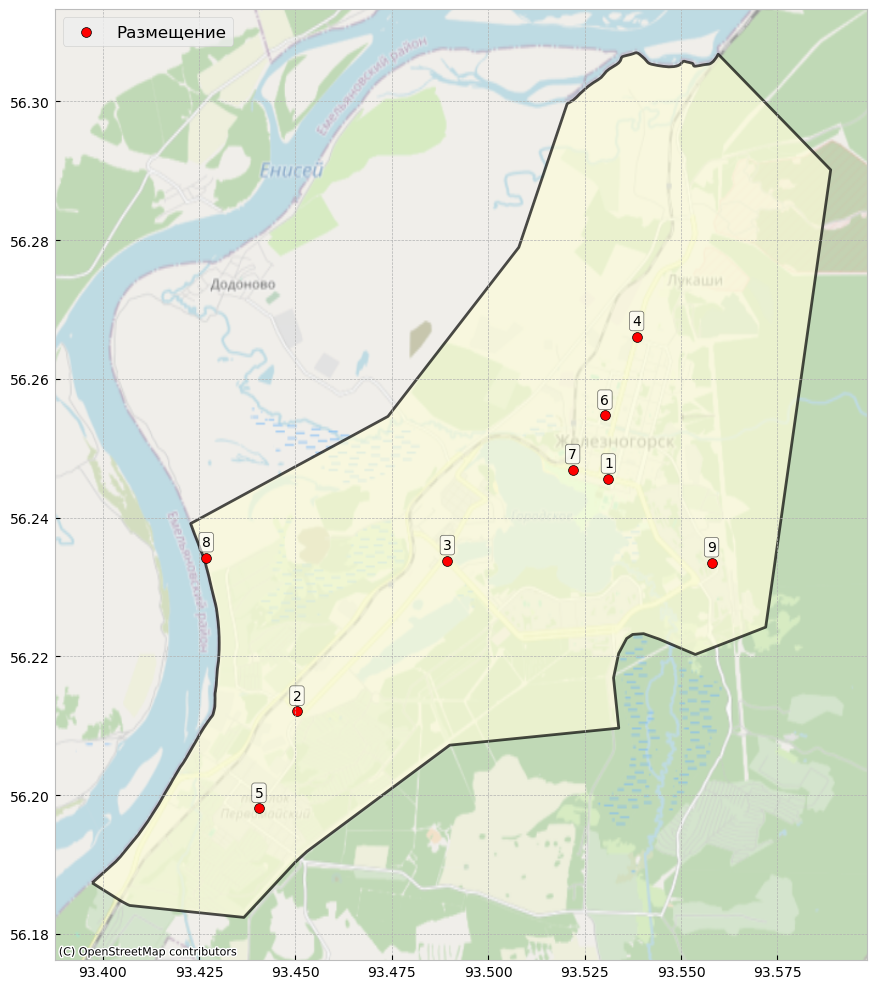

In [ ]:
cutoff = 10
target_set = None
target_metric = 1  # 0 - по кол-ву подразделений, 1 - по ИП 
target_value = 100  # значение для остановки расчета

# 1. Загрузка данных

# Загрузка ГДС
from fire_units.metrics import CoverIndexBuildingADD
from fire_units.settings import DEFAULT_SPEEDS
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState, get_atm
from graphs.speeds import kmh_to_mm, set_graph_travel_times



# Установка свойств графа
G = ox.project_graph(G)
estimated_utm_crs = G.graph['crs']
print(f'Получен граф дорог с количеством узлов - {G.number_of_nodes()} и ребер {G.number_of_edges()}. СК: {estimated_utm_crs}')

# Установка времени следования по участкам дорог
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)


# Загрузка зданий
target_layer_gdf = gpd.read_file('G:/QGIS/Железногорск/data/Железногорск.gpkg', layer='buildings')
# target_layer_gdf.set_crs(crs=estimated_utm_crs, inplace=True)



target_layer_gdf = ox.projection.project_gdf(target_layer_gdf, to_crs=estimated_utm_crs)
centroids = target_layer_gdf.geometry.centroid
target_layer_gdf[DATA_NODE_FIELD] = ox.nearest_nodes(G, centroids.x, centroids.y)
print(f'Количество объектов в целевом слое - {len(target_layer_gdf)}')
if DATA_SAMPLE_SIZE:
    target_layer_gdf = target_layer_gdf.sample(DATA_SAMPLE_SIZE)
print(f'Из них в расчет взято - {len(target_layer_gdf)}')
print(f'СК слоя зданий - {target_layer_gdf.crs}')

# Загрузка существующих подразделений:
existed_units_dict = None




# 2. Расчет ADD
# Расчет матрицы прибытия
matrix = get_atm(G,
                 data              = target_layer_gdf,
                 # data_sample_size  = DATA_SAMPLE_SIZE,
                 data_node_field   = DATA_NODE_FIELD,
                 weight            = EDGES_WEIGHT_FIELD,
                 cutoff            = cutoff,
                 data_cutoff_field = DATA_CUTOFF_FIELD,
                 target_set        = target_set,
                 print_calc_states = True,
                 )

# 3. Сборка решения
# ================================================================================================
## Выбор метрики
metric_func  = CoverIndexBuildingADD(target_layer_gdf, ip_val=cutoff)

## Функция обратного вызова при расчете подразделений
def after_mclp_function(best_metric, dynamic_nodes, **kwargs):
    metric = round(best_metric, 2)
    print(f'Подразделений: {len(dynamic_nodes)}, Метрика: {metric}')

## Функция остановки
def stop_case (value, dynamic_nodes, **kwargs):
    if target_metric == 0:
        return len(dynamic_nodes) >= target_value
    elif target_metric == 1:
        return value >= target_value


## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = FirstArrivalUnitState(),
    matrix              = matrix,
    metric_function     = metric_func,
    ip_val              = cutoff,
    stop_case_function  = stop_case,
    names_pattern       = NAMES_PATTERN,
    start_names_index   = START_NAMES_INDEX,
    after_mclp_function = after_mclp_function,
    check_for_best_time = True,
)

# 4. Расчет
# ================================================================================================
best_nodes, best_metric = add(
    env           = G,
    dynamic_nodes = None,
    static_nodes  = existed_units_dict,
    # area          = points_mask,
)


# 5. Печать карты
g_nodes = ox.graph_to_gdfs(G, edges=False)
plot_map(bounds, ox.projection.project_gdf(g_nodes, to_latlong=True), best_nodes)




### Расчет с использованием восстановленного графа

Получен граф дорог с количеством узлов - 11917 и ребер 50102. СК: EPSG:32646
Количество объектов в целевом слое - 3041
Из них в расчет взято - 3041
СК слоя зданий - EPSG:32646
|########################################| 100.0%
Подразделений: 1, Метрика: 66.06
Подразделений: 2, Метрика: 96.81
Подразделений: 3, Метрика: 98.78
Подразделений: 4, Метрика: 99.64
Подразделений: 5, Метрика: 99.8
Подразделений: 6, Метрика: 99.9
Подразделений: 7, Метрика: 99.93
Подразделений: 8, Метрика: 99.97
Подразделений: 9, Метрика: 100.0


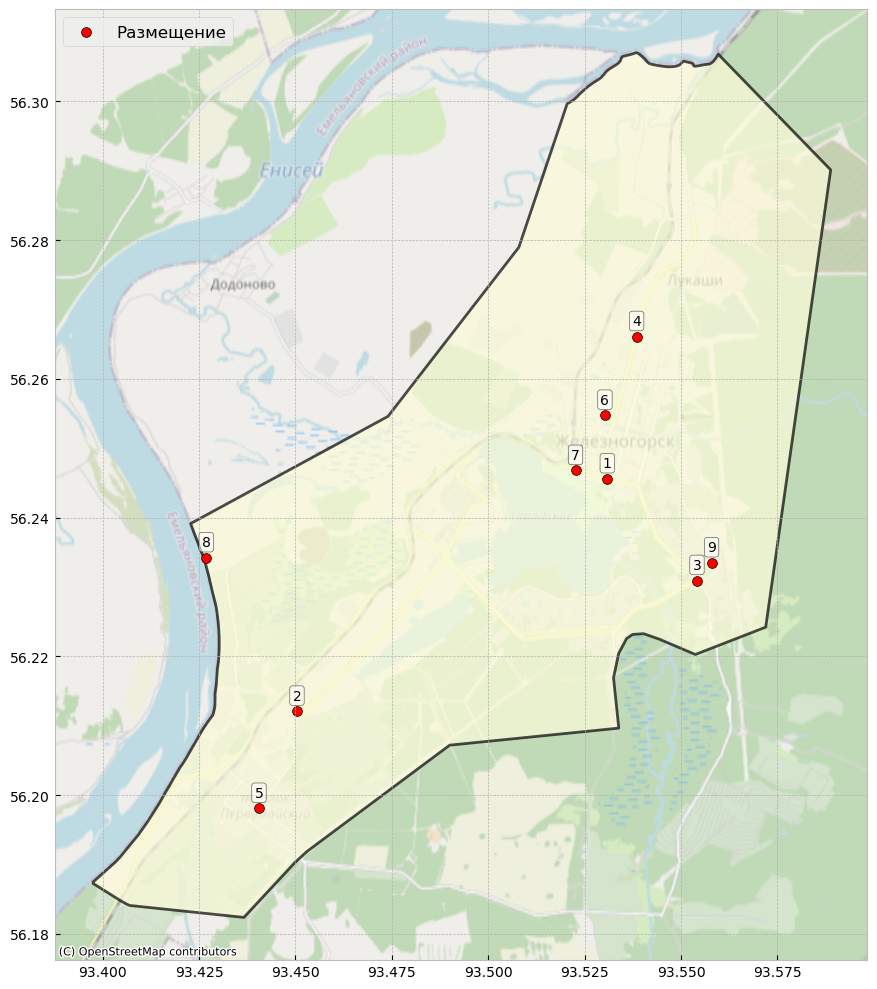

In [12]:
cutoff = 10
target_set = None
target_metric = 1  # 0 - по кол-ву подразделений, 1 - по ИП 
target_value = 100  # значение для остановки расчета

from graphs.algorithms import graph_rise_from_gpkg

# 1. Загрузка данных

# Загрузка ГДС
from fire_units.metrics import CoverIndexBuildingADD
from fire_units.settings import DEFAULT_SPEEDS
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState, get_atm
from graphs.speeds import kmh_to_mm, set_graph_travel_times


# Воссоздание графа с расчетом времени проезда
roads_gdf = gpd.read_file('roads_temp.gpkg')
## Проверяем наличие нужных полей
columns_list = ['highway', 'oneway', 'lanes']
for col in columns_list:
    if not col in roads_gdf.columns:
        print(f'Поле {col} отсутствует в списке полей входящего слоя дорожной сети!')
## Получаем все поля из слоя дорог, за исключением полей 'geometry' и полей ключей
## ВАЖНО! Также удаляем поле 'length', так как оно пересчитывается в функции graph_rise_from_gpkg
key_fields = ['u', 'v', 'key', 'geometry', 'osmid', 'length']
columns_list = [col for col in roads_gdf.columns if col not in key_fields]

## Реконструкция графа
G = graph_rise_from_gpkg(roads_gdf,
                        columns_list = columns_list)

## Установка свойств графа
G = ox.project_graph(G)
estimated_utm_crs = G.graph['crs']
print(f'Получен граф дорог с количеством узлов - {G.number_of_nodes()} и ребер {G.number_of_edges()}. СК: {estimated_utm_crs}')

# Установка времени следования по участкам дорог
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)





# Загрузка зданий
target_layer_gdf = gpd.read_file('G:/QGIS/Железногорск/data/Железногорск.gpkg', layer='buildings')
# target_layer_gdf.set_crs(crs=estimated_utm_crs, inplace=True)
target_layer_gdf = ox.projection.project_gdf(target_layer_gdf, to_crs=estimated_utm_crs)
centroids = target_layer_gdf.geometry.centroid
target_layer_gdf[DATA_NODE_FIELD] = ox.nearest_nodes(G, centroids.x, centroids.y)
print(f'Количество объектов в целевом слое - {len(target_layer_gdf)}')
if DATA_SAMPLE_SIZE:
    target_layer_gdf = target_layer_gdf.sample(DATA_SAMPLE_SIZE)
print(f'Из них в расчет взято - {len(target_layer_gdf)}')
print(f'СК слоя зданий - {target_layer_gdf.crs}')

# Загрузка существующих подразделений:
existed_units_dict = None




# 2. Расчет ADD
# Расчет матрицы прибытия
matrix = get_atm(G,
                 data              = target_layer_gdf,
                 # data_sample_size  = DATA_SAMPLE_SIZE,
                 data_node_field   = DATA_NODE_FIELD,
                 weight            = EDGES_WEIGHT_FIELD,
                 cutoff            = cutoff,
                 data_cutoff_field = DATA_CUTOFF_FIELD,
                 target_set        = target_set,
                 print_calc_states = True,
                 )

# 3. Сборка решения
# ================================================================================================
## Выбор метрики
metric_func  = CoverIndexBuildingADD(target_layer_gdf, ip_val=cutoff)

## Функция обратного вызова при расчете подразделений
def after_mclp_function(best_metric, dynamic_nodes, **kwargs):
    metric = round(best_metric, 2)
    print(f'Подразделений: {len(dynamic_nodes)}, Метрика: {metric}')

## Функция остановки
def stop_case (value, dynamic_nodes, **kwargs):
    if target_metric == 0:
        return len(dynamic_nodes) >= target_value
    elif target_metric == 1:
        return value >= target_value


## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = FirstArrivalUnitState(),
    matrix              = matrix,
    metric_function     = metric_func,
    ip_val              = cutoff,
    stop_case_function  = stop_case,
    names_pattern       = NAMES_PATTERN,
    start_names_index   = START_NAMES_INDEX,
    after_mclp_function = after_mclp_function,
    check_for_best_time = True,
)

# 4. Расчет
# ================================================================================================
best_nodes, best_metric = add(
    env           = G,
    dynamic_nodes = None,
    static_nodes  = existed_units_dict,
    # area          = points_mask,
)


# 5. Печать карты
g_nodes = ox.graph_to_gdfs(G, edges=False)
plot_map(bounds, ox.projection.project_gdf(g_nodes, to_latlong=True), best_nodes)




# Тесты

In [19]:
matrix = get_atm(G,
                 data              = target_layer_gdf,
                 # data_sample_size  = DATA_SAMPLE_SIZE,
                 data_node_field   = DATA_NODE_FIELD,
                 weight            = EDGES_WEIGHT_FIELD,
                 cutoff            = 10,
                 data_cutoff_field = DATA_CUTOFF_FIELD,
                 target_set        = target_set,
                 print_calc_states = True,
                 )
matrix

|########################################| 100.0%


,1273388056,1273389243,1273388639,1273388507,1273389587,1273389302,1273388622,1273389507,1273388845,1273389558,...,2003983317,12860419667,1217405893,3943712118,1273388275,12860419668,2127476592,2129349874,4019705219,1273389207
0,1.0,2.650772,2.897571,3.190217,3.276357,3.511573,3.529368,3.728366,3.828236,4.146617,...,9.929654,9.930875,9.93647,9.937928,9.948565,9.963799,9.969112,9.983417,9.985567,9.998311
1,1.0,2.650772,2.897571,3.190217,3.276357,3.511573,3.529368,3.728366,3.828236,4.146617,...,9.929654,9.930875,9.93647,9.937928,9.948565,9.963799,9.969112,9.983417,9.985567,9.998311
2,1.0,2.650772,2.897571,3.190217,3.276357,3.511573,3.529368,3.728366,3.828236,4.146617,...,9.929654,9.930875,9.93647,9.937928,9.948565,9.963799,9.969112,9.983417,9.985567,9.998311
3,1.0,2.650772,2.897571,3.190217,3.276357,3.511573,3.529368,3.728366,3.828236,4.146617,...,9.929654,9.930875,9.93647,9.937928,9.948565,9.963799,9.969112,9.983417,9.985567,9.998311
4,1.0,2.650772,2.897571,3.190217,3.276357,3.511573,3.529368,3.728366,3.828236,4.146617,...,9.929654,9.930875,9.93647,9.937928,9.948565,9.963799,9.969112,9.983417,9.985567,9.998311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
598,1.0,2.650772,2.897571,3.190217,3.276357,3.511573,3.529368,3.728366,3.828236,4.146617,...,9.929654,9.930875,9.93647,9.937928,9.948565,9.963799,9.969112,9.983417,9.985567,9.998311
599,1.0,2.650772,2.897571,3.190217,3.276357,3.511573,3.529368,3.728366,3.828236,4.146617,...,9.929654,9.930875,9.93647,9.937928,9.948565,9.963799,9.969112,9.983417,9.985567,9.998311
600,1.0,2.650772,2.897571,3.190217,3.276357,3.511573,3.529368,3.728366,3.828236,4.146617,...,9.929654,9.930875,9.93647,9.937928,9.948565,9.963799,9.969112,9.983417,9.985567,9.998311
601,1.0,2.650772,2.897571,3.190217,3.276357,3.511573,3.529368,3.728366,3.828236,4.146617,...,9.929654,9.930875,9.93647,9.937928,9.948565,9.963799,9.969112,9.983417,9.985567,9.998311


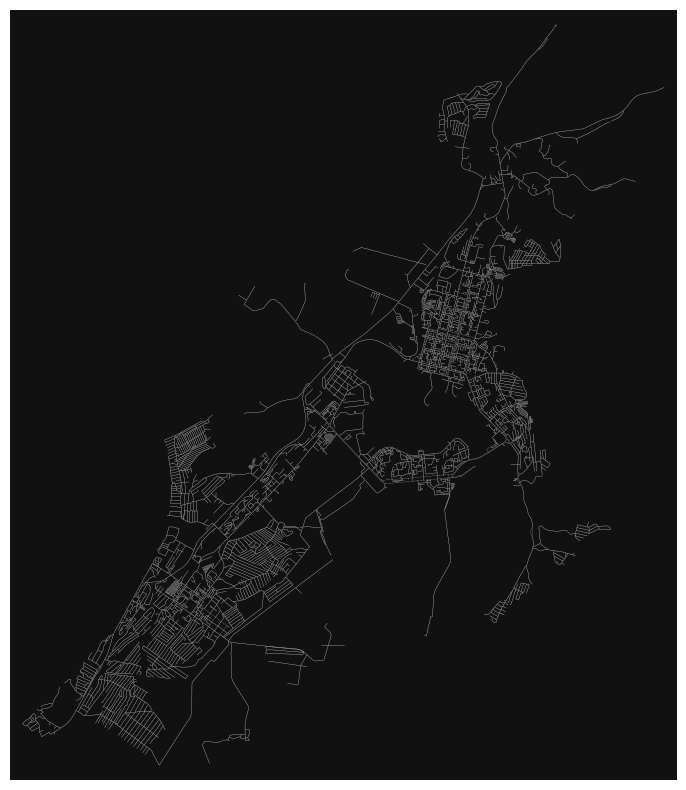

(<Figure size 1000x1000 with 1 Axes>, <Axes: >)

In [20]:
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, figsize=(10, 10))

In [17]:
times, _ = FirstArrivalUnitState()(G, [10])
times

10        1.0
11        2.0
9         2.0
12        3.0
8         3.0
        ...  
1872    136.0
1893    137.0
1903    138.0
1906    139.0
1917    140.0
Name: times, Length: 3293, dtype: float64

In [18]:
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes['arrival_time'] = times
g_nodes

,x,y,geometry,arrival_time
osmid,,,,
0,522170.510313,6.224067e+06,POINT (522170.51 6224067.182),11.0
1,521988.828514,6.223955e+06,POINT (521988.829 6223954.565),10.0
2,521913.372686,6.223901e+06,POINT (521913.373 6223900.597),9.0
1481,521973.563346,6.223993e+06,POINT (521973.563 6223992.986),11.0
3,521853.869548,6.223851e+06,POINT (521853.87 6223850.697),8.0
...,...,...,...,...
3324,519659.202026,6.219332e+06,POINT (519659.202 6219331.853),91.0
3325,519634.734679,6.219321e+06,POINT (519634.735 6219321.089),90.0
3326,519628.470486,6.219305e+06,POINT (519628.47 6219305.412),89.0


<Axes: >

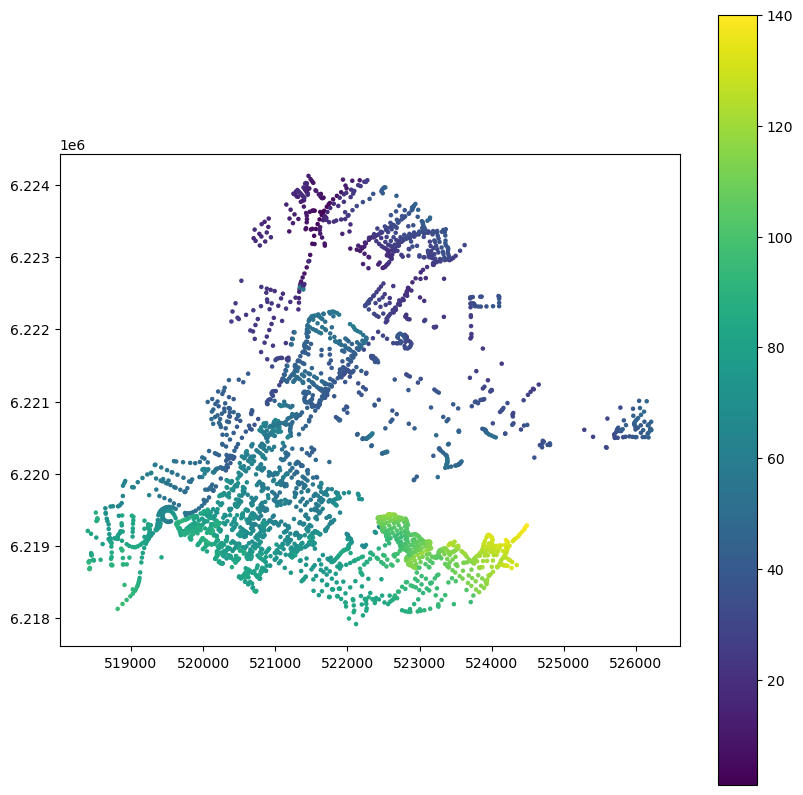

In [19]:
g_nodes.plot(column='arrival_time', figsize=(10, 10), markersize=5, legend=True)

In [20]:
ox.graph_to_gdfs(G, nodes=False)

highway  oneway lanes  reversed      length  \
u    v    key                                                  
0    1    0    secondary   False     2     False  213.754270   
          1    secondary   False     2     False  213.754270   
1    0    0    secondary   False     2     False  213.754270   
          1    secondary   False     2     False  213.754270   
     2    0    secondary   False     2     False   92.768940   
...                  ...     ...   ...       ...         ...   
3327 3326 1      service   False   NaN     False   14.410907   
     3328 0      service   False   NaN     False   36.478469   
          1      service   False   NaN     False   36.478469   
3336 3337 0      service   False   NaN     False   15.678278   
          1      service   False   NaN     False   15.678278   

                                                        geometry  
u    v    key                                                     
0    1    0    LINESTRING (522170.51 6224067.182, 521988.829 ...  
          1    LINESTRING (522170.51 6224067.182, 521988.829 ...  
1    0    0    LINESTRING (521988.829 6223954.565, 522170.51 ...  
          1    LINESTRING (521988.829 6223954.565, 522170.51 ...  
     2    0    LINESTRING (521988.829 6223954.565, 521913.373...  
...                                                          ...  
3327 3326 1    LINESTRING (519632.035 6219291.448, 519628.47 ...  
     3328 0    LINESTRING (519632.035 6219291.448, 519648.531...  
          1    LINESTRING (519632.035 6219291.448, 519648.531...  
3336 3337 0    LINESTRING (520013.572 6219479.529, 520002.201...  
          1    LINESTRING (520013.572 6219479.529, 520002.201...  

[13863 rows x 6 columns]